# 02 — Ricerca dei parametri Praat: fase 0 (benchmark) e fase A (range)


- **Fase 0 — benchmark:** tempo di estrazione per file con i parametri standard di Praat.
- **Fase A — range:** griglia 0–1, **un parametro alla volta** (gli altri allo standard) *silence threshold, octave cost, octave-jump cost, voiced/unvoiced cost*.
  Per ogni configurazione e ogni finestra (50/100/200/500 ms) misura quante finestre risultano senza voce
  e quante misure risultano indefinite (NaN). Serve a fissare i limiti per la griglia della fase B.

**Campione:** 1.000 file estratti **casualmente** dal train di ASVspoof 2019 LA (seed fisso).

**Feature per finestra (8):** F0 media, F0 dev. std, jitter (local), shimmer (local),
HNR media, HNR dev. std, intensità media, intensità dev. std.
Regola: finestra senza frame sonori → tutte le feature a 0

**Procedura Praat (manuale, "Voice 6"):** `To Pitch (cc)` → `Sound & Pitch: To PointProcess (cc)`.
HNR con `To Harmonicity (cc)` (75 Hz)
HNR e intensità **non dipendono** dai 4 parametri: si calcolano una volta per file.

In [1]:
import os, sys, re, json, time, math, subprocess
from pathlib import Path
from concurrent.futures import ProcessPoolExecutor

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

try:
    import parselmouth
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "praat-parselmouth"], check=True)
    import parselmouth
from parselmouth.praat import call

INPUT_ROOT = Path(os.environ.get("INPUT_ROOT", "/kaggle/input"))
OUT_DIR = Path(os.environ.get("OUT_DIR", "/kaggle/working/praat_search"))
OUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
N_FILES = int(os.environ.get("N_FILES", 1000))       # campione casuale dal train
N_BENCH = int(os.environ.get("N_BENCH", 20))         # file per il benchmark
N_WORKERS = os.cpu_count() or 1
RUN_PHASE_A = True                                    # metti False per fermarti al benchmark

# --- Parametri fissi (Pitch Imperfect + standard Praat dal manuale) ---
PITCH_FLOOR, PITCH_CEILING = 75.0, 500.0             # Pitch Imperfect, p. 5
MAX_CANDIDATES, VERY_ACCURATE = 15, "no"            # standard Praat
VOICING_THRESHOLD = 0.45                             # standard Praat (non cercato dal paper)
TIME_STEP = 0.0                                      # 0 = automatico
PERIOD_FLOOR = 0.8 / PITCH_CEILING                   # manuale, "Voice 2. Jitter"
PERIOD_CEILING = 1.25 / PITCH_FLOOR
MAX_PERIOD_FACTOR, MAX_AMPLITUDE_FACTOR = 1.3, 1.6   # standard Praat
HNR_TIME_STEP, HNR_SILENCE, HNR_PERIODS = 0.01, 0.1, 1.0   # "one period per window" (Pitch Imperfect, p. 6)

# --- I 4 parametri cercati da Pitch Imperfect: valori standard Praat ---
STANDARD = {"silence_threshold": 0.03, "octave_cost": 0.01,
            "octave_jump_cost": 0.35, "voiced_unvoiced_cost": 0.14}
GRID_VALUES = [round(v, 2) for v in np.linspace(0.0, 1.0, 11)]   # 0.0, 0.1, ..., 1.0
WINDOWS_MS = [50, 100, 200, 500]

FEATURES = ["f0_mean", "f0_std", "jitter_local", "shimmer_local",
            "hnr_mean", "hnr_std", "intensity_mean", "intensity_std"]

print("parselmouth", parselmouth.__version__, "| Praat", parselmouth.PRAAT_VERSION, "| core CPU:", N_WORKERS)

parselmouth 0.4.7 | Praat 6.1.38 | core CPU: 4


In [2]:
def find_la_root(root):
    for dirpath, dirnames, _ in os.walk(root):
        dirnames[:] = [d for d in dirnames if d != "flac"]
        if "ASVspoof2019_LA_cm_protocols" in dirnames:
            return Path(dirpath)
    raise RuntimeError("Cartella con ASVspoof2019_LA_cm_protocols non trovata: imposta LA_ROOT a mano.")

LA_ROOT = find_la_root(INPUT_ROOT)
proto = [p for p in (LA_ROOT / "ASVspoof2019_LA_cm_protocols").iterdir() if re.search(r"cm[._]train[._]trn", p.name)]
assert len(proto) == 1, proto
train = pd.read_csv(proto[0], sep=r"\s+", header=None, dtype=str, keep_default_na=False, engine="python",
                    names=["speaker", "utt_id", "unused", "attack", "label"])
assert len(train) > 0 and set(train["label"]) <= {"bonafide", "spoof"}
train["attack"] = train["attack"].replace("-", "bonafide")
train["path"] = [str(LA_ROOT / "ASVspoof2019_LA_train" / "flac" / f"{u}.flac") for u in train["utt_id"]]

sample = train.sample(n=min(N_FILES, len(train)), random_state=SEED).reset_index(drop=True)
sample[["utt_id", "speaker", "attack", "label"]].to_csv(OUT_DIR / "sample_1000.csv", index=False)

print("LA_ROOT:", LA_ROOT)
print("File nel campione:", len(sample))
print("Etichette:", sample["label"].value_counts().to_dict())
print("Attacchi:", sample["attack"].value_counts().sort_index().to_dict())
print("Speaker:", sample["speaker"].nunique())

LA_ROOT: /kaggle/input/datasets/angelopaldino/asvspoof2019-train-dev/LA
File nel campione: 1000
Etichette: {'spoof': 908, 'bonafide': 92}
Attacchi: {'A01': 161, 'A02': 145, 'A03': 146, 'A04': 134, 'A05': 163, 'A06': 159, 'bonafide': 92}
Speaker: 20


In [3]:
def make_windows(duration, w):
    starts = np.arange(0.0, duration, w)
    ends = np.minimum(starts + w, duration)
    keep = (ends - starts) >= w / 2
    return starts[keep], ends[keep]

def frames_in(times, a, b):
    return (times >= a) & (times < b)

def window_features(snd, pitch, pp, harm_t, harm_v, int_t, int_v, a, b, pitch_t, f0):
    # Restituisce (vettore di 8 feature con NaN, voiced: bool)
    m = frames_in(pitch_t, a, b)
    f0w = f0[m]
    f0w = f0w[f0w > 0]
    if len(f0w) == 0:
        return np.zeros(len(FEATURES)), False
    out = np.full(len(FEATURES), np.nan)
    out[0] = f0w.mean()
    out[1] = f0w.std() if len(f0w) >= 2 else np.nan
    try:
        out[2] = call(pp, "Get jitter (local)", a, b, PERIOD_FLOOR, PERIOD_CEILING, MAX_PERIOD_FACTOR)
    except Exception:
        pass
    try:
        out[3] = call([snd, pp], "Get shimmer (local)", a, b, PERIOD_FLOOR, PERIOD_CEILING,
                      MAX_PERIOD_FACTOR, MAX_AMPLITUDE_FACTOR)
    except Exception:
        pass
    hw = harm_v[frames_in(harm_t, a, b)]
    hw = hw[hw > -100]                      # Praat usa -200 dB per i frame silenziosi
    if len(hw) >= 1:
        out[4] = hw.mean()
        out[5] = hw.std() if len(hw) >= 2 else np.nan
    iw = int_v[frames_in(int_t, a, b)]
    iw = iw[np.isfinite(iw)]
    if len(iw) >= 1:
        out[6] = iw.mean()
        out[7] = iw.std() if len(iw) >= 2 else np.nan
    return out, True

def analyse_file(path, configs, windows_ms=WINDOWS_MS):
    # Per ogni configurazione e finestra: conteggi di finestre, finestre senza voce, NaN per feature
    snd = parselmouth.Sound(path)
    harm = call(snd, "To Harmonicity (cc)", HNR_TIME_STEP, PITCH_FLOOR, HNR_SILENCE, HNR_PERIODS)
    harm_t, harm_v = np.asarray(harm.xs()), np.asarray(harm.values[0])
    inten = snd.to_intensity(minimum_pitch=PITCH_FLOOR)
    int_t, int_v = np.asarray(inten.xs()), np.asarray(inten.values[0])
    rows = []
    for cfg_id, cfg in configs:
        pitch = call(snd, "To Pitch (cc)", TIME_STEP, PITCH_FLOOR, MAX_CANDIDATES, VERY_ACCURATE,
                     cfg["silence_threshold"], VOICING_THRESHOLD, cfg["octave_cost"],
                     cfg["octave_jump_cost"], cfg["voiced_unvoiced_cost"], PITCH_CEILING)
        pitch_t = np.asarray(pitch.xs())
        f0 = np.asarray(pitch.selected_array["frequency"])
        pp = call([snd, pitch], "To PointProcess (cc)")
        for w_ms in windows_ms:
            starts, ends = make_windows(snd.duration, w_ms / 1000)
            n_voiced, nan_counts, f0_sum = 0, np.zeros(len(FEATURES), dtype=int), 0.0
            for a, b in zip(starts, ends):
                vec, voiced = window_features(snd, pitch, pp, harm_t, harm_v, int_t, int_v, a, b, pitch_t, f0)
                if voiced:
                    n_voiced += 1
                    nan_counts += np.isnan(vec)
            rows.append({"cfg_id": cfg_id, "window_ms": w_ms, "n_windows": len(starts),
                         "n_voiced": n_voiced, "voiced_frame_frac": float((f0 > 0).mean()) if len(f0) else np.nan,
                         **{f"nan_{f}": int(c) for f, c in zip(FEATURES, nan_counts)}})
    return rows

def extract_file_features(path, cfg, w_ms):
    # Matrice (n_finestre, 8) con la regola finale: NaN -> 0, finestre senza voce -> 0
    snd = parselmouth.Sound(path)
    harm = call(snd, "To Harmonicity (cc)", HNR_TIME_STEP, PITCH_FLOOR, HNR_SILENCE, HNR_PERIODS)
    inten = snd.to_intensity(minimum_pitch=PITCH_FLOOR)
    pitch = call(snd, "To Pitch (cc)", TIME_STEP, PITCH_FLOOR, MAX_CANDIDATES, VERY_ACCURATE,
                 cfg["silence_threshold"], VOICING_THRESHOLD, cfg["octave_cost"],
                 cfg["octave_jump_cost"], cfg["voiced_unvoiced_cost"], PITCH_CEILING)
    pp = call([snd, pitch], "To PointProcess (cc)")
    harm_t, harm_v = np.asarray(harm.xs()), np.asarray(harm.values[0])
    int_t, int_v = np.asarray(inten.xs()), np.asarray(inten.values[0])
    pitch_t, f0 = np.asarray(pitch.xs()), np.asarray(pitch.selected_array["frequency"])
    starts, ends = make_windows(snd.duration, w_ms / 1000)
    X = np.zeros((len(starts), len(FEATURES)), dtype=np.float32)
    for i, (a, b) in enumerate(zip(starts, ends)):
        vec, _ = window_features(snd, pitch, pp, harm_t, harm_v, int_t, int_v, a, b, pitch_t, f0)
        X[i] = np.nan_to_num(vec, nan=0.0)
    return X, starts

# Configurazioni della fase A: standard + un parametro alla volta su 0.0..1.0
CONFIGS = [("standard", dict(STANDARD))]
for p in STANDARD:
    for v in GRID_VALUES:
        cfg = dict(STANDARD); cfg[p] = v
        CONFIGS.append((f"{p}={v}", cfg))
print("Configurazioni fase A:", len(CONFIGS))

Configurazioni fase A: 45


# Benchmark
tempo per file con sola configurazione standard e tutte le finestre

In [4]:
bench = sample.head(N_BENCH)
t0 = time.perf_counter()
for p in bench["path"]:
    analyse_file(p, CONFIGS[:1])
t_std = (time.perf_counter() - t0) / len(bench)

t0 = time.perf_counter()
analyse_file(bench["path"].iloc[0], CONFIGS[:6])
t_cfg = (time.perf_counter() - t0) / 6

est_h = len(sample) * len(CONFIGS) * t_cfg / max(N_WORKERS, 1) / 3600
print(f"Tempo per file, 1 configurazione e 4 finestre: {t_std:.3f} s")
print(f"Tempo stimato fase A ({len(sample)} file x {len(CONFIGS)} configurazioni, {N_WORKERS} core): ~{est_h:.2f} h")

X, starts = extract_file_features(bench["path"].iloc[0], STANDARD, 200)
print(f"\nEsempio: {bench['utt_id'].iloc[0]} ({bench['label'].iloc[0]}), finestre da 200 ms -> matrice {X.shape}")
pd.DataFrame(X, columns=FEATURES, index=np.round(starts, 2)).round(3).head(10)

Tempo per file, 1 configurazione e 4 finestre: 0.129 s
Tempo stimato fase A (1000 file x 45 configurazioni, 4 core): ~0.19 h

Esempio: LA_T_1136756 (spoof), finestre da 200 ms -> matrice (13, 8)


,f0_mean,f0_std,jitter_local,shimmer_local,hnr_mean,hnr_std,intensity_mean,intensity_std
0.0,0.000000,0.000,0.000,0.000,0.000,0.000,0.000000,0.000
0.2,0.000000,0.000,0.000,0.000,0.000,0.000,0.000000,0.000
0.4,0.000000,0.000,0.000,0.000,0.000,0.000,0.000000,0.000
0.6,0.000000,0.000,0.000,0.000,0.000,0.000,0.000000,0.000
0.8,0.000000,0.000,0.000,0.000,0.000,0.000,0.000000,0.000
1.0,0.000000,0.000,0.000,0.000,0.000,0.000,0.000000,0.000
1.2,0.000000,0.000,0.000,0.000,0.000,0.000,0.000000,0.000
1.4,274.230988,13.445,0.010,0.116,13.555,4.055,79.994003,7.215
1.6,246.860992,9.598,0.019,0.096,12.470,5.354,72.642998,3.880
1.8,204.936005,10.595,0.016,0.135,14.499,3.291,78.738998,4.945


# RANGE DEI PARAMETRI

In [5]:
PART_DIR = OUT_DIR / "phaseA_parts"
PART_DIR.mkdir(exist_ok=True)
CHUNK = 100

def worker(args):
    utt_id, label, path = args
    try:
        rows = analyse_file(path, CONFIGS)
        for r in rows:
            r.update(utt_id=utt_id, label=label, error="")
        return rows
    except Exception as e:
        return [{"utt_id": utt_id, "label": label, "error": repr(e)}]

if RUN_PHASE_A:
    tasks = list(zip(sample["utt_id"], sample["label"], sample["path"]))
    done = set()
    for f in PART_DIR.glob("part_*.csv"):
        done |= set(pd.read_csv(f, usecols=["utt_id"])["utt_id"])
    todo = [t for t in tasks if t[0] not in done]
    print(f"Già elaborati: {len(done)} | da elaborare: {len(todo)}")
    t0 = time.perf_counter()
    with ProcessPoolExecutor(max_workers=N_WORKERS) as ex:
        for k in range(0, len(todo), CHUNK):
            chunk = todo[k:k + CHUNK]
            rows = [r for rs in ex.map(worker, chunk) for r in rs]
            pd.DataFrame(rows).to_csv(PART_DIR / f"part_{len(done) + k:05d}.csv", index=False)
            print(f"  {len(done) + k + len(chunk)}/{len(tasks)} file  ({(time.perf_counter() - t0) / 60:.1f} min)")

Già elaborati: 0 | da elaborare: 1000
  100/1000 file  (4.1 min)
  200/1000 file  (8.2 min)
  300/1000 file  (12.3 min)
  400/1000 file  (16.1 min)
  500/1000 file  (20.3 min)
  600/1000 file  (24.2 min)
  700/1000 file  (28.2 min)
  800/1000 file  (32.3 min)
  900/1000 file  (36.5 min)
  1000/1000 file  (40.5 min)


In [6]:
res = pd.concat([pd.read_csv(f) for f in sorted(PART_DIR.glob("part_*.csv"))], ignore_index=True)
errors = res[res["error"].fillna("") != ""]
print("File con errore:", errors["utt_id"].nunique())
if len(errors):
    display(errors[["utt_id", "error"]].drop_duplicates().head())
res = res[res["error"].fillna("") == ""]

nan_cols = [f"nan_{f}" for f in FEATURES]
agg = res.groupby(["cfg_id", "window_ms"])[["n_windows", "n_voiced"] + nan_cols].sum()
summary = pd.DataFrame({
    "pct_zero_windows": 100 * (1 - agg["n_voiced"] / agg["n_windows"]),
    **{f"pct_nan_{f}": 100 * agg[f"nan_{f}"] / agg["n_voiced"].replace(0, np.nan) for f in FEATURES},
}).round(2)
# voiced frame fraction per classe (informativo)
vf = res[res["window_ms"] == WINDOWS_MS[0]].groupby(["cfg_id", "label"])["voiced_frame_frac"].mean().unstack().round(3)

summary.to_csv(OUT_DIR / "phaseA_summary.csv")
vf.to_csv(OUT_DIR / "phaseA_voiced_frac_by_label.csv")
print("File elaborati:", res["utt_id"].nunique())
display(summary.loc["standard"])

File con errore: 0
File elaborati: 1000


,pct_zero_windows,pct_nan_f0_mean,pct_nan_f0_std,pct_nan_jitter_local,pct_nan_shimmer_local,pct_nan_hnr_mean,pct_nan_hnr_std,pct_nan_intensity_mean,pct_nan_intensity_std
window_ms,,,,,,,,,
50,45.70,0.0,2.42,10.75,20.43,6.96,13.45,0.02,0.08
100,37.66,0.0,1.20,6.17,12.83,3.56,6.98,0.00,0.01
200,31.22,0.0,0.43,1.96,4.31,1.76,2.73,0.00,0.00
500,22.59,0.0,0.21,0.96,1.92,1.19,1.81,0.00,0.00


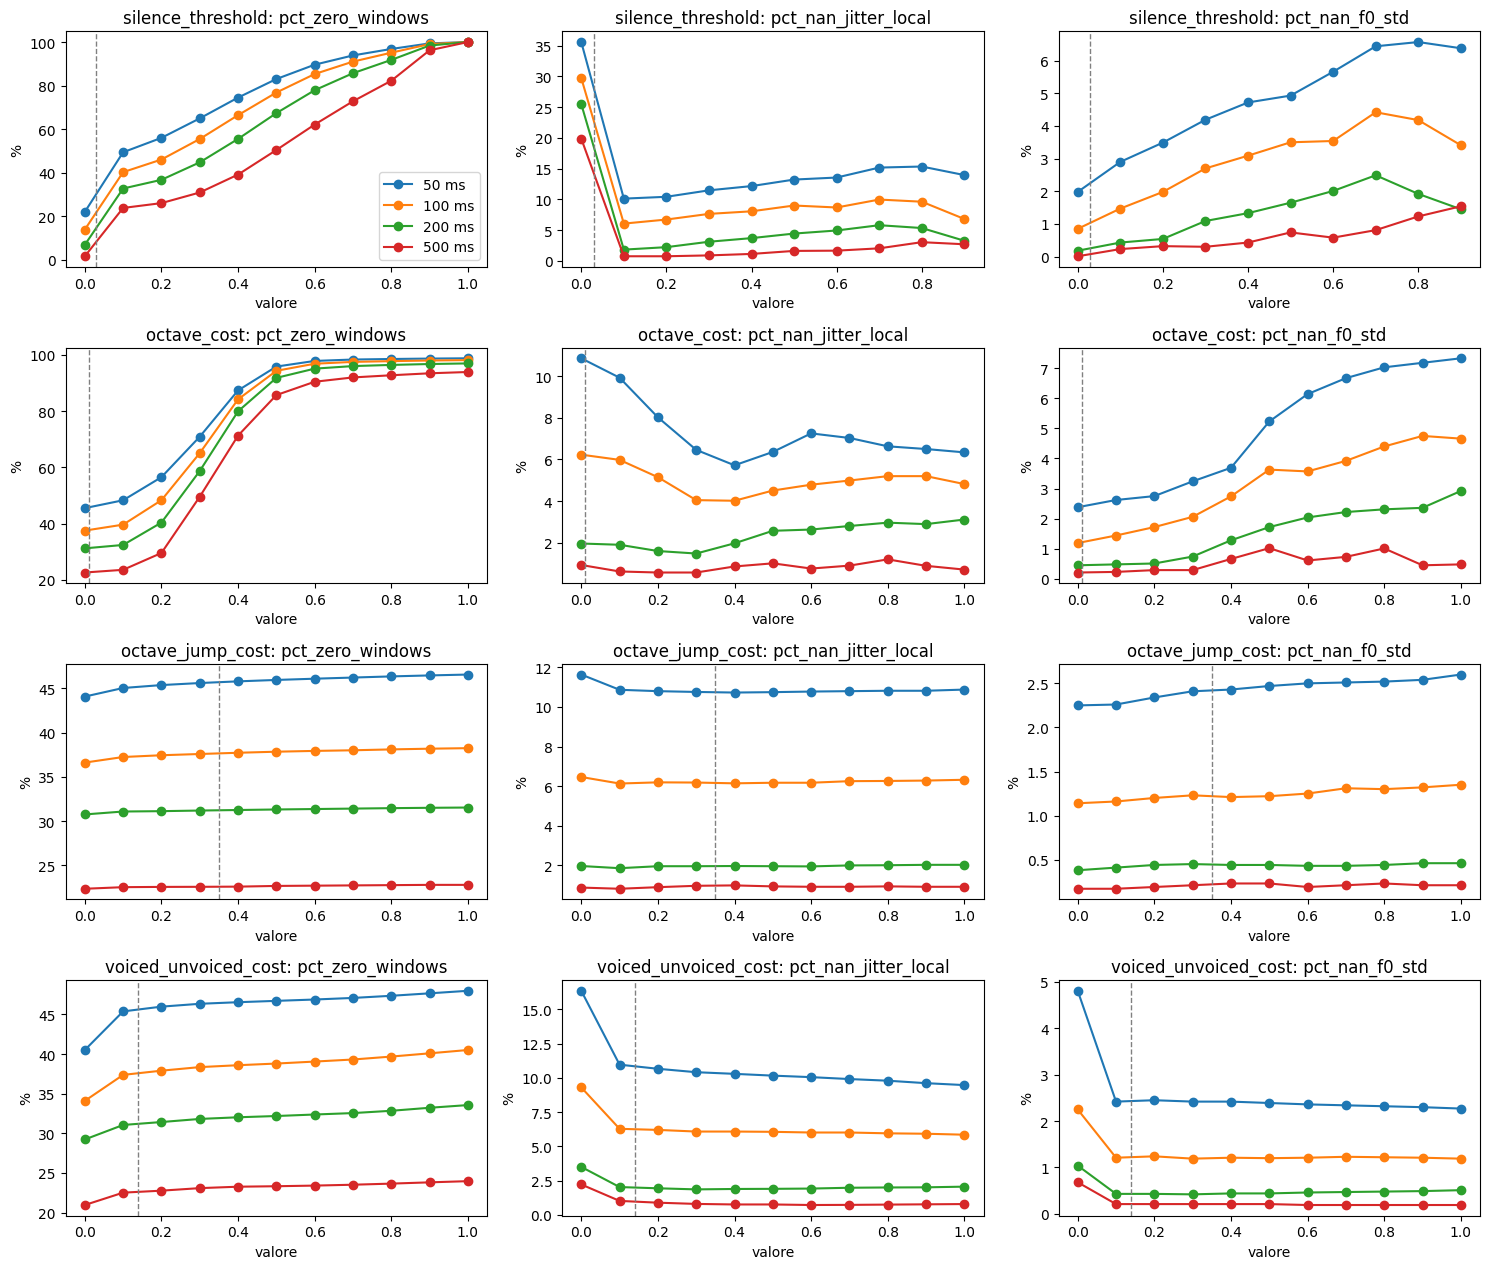

In [7]:
import matplotlib.pyplot as plt

param_names = list(STANDARD)
fig, axes = plt.subplots(len(param_names), 3, figsize=(15, 3.2 * len(param_names)), squeeze=False)
for i, p in enumerate(param_names):
    sub = summary.reset_index()
    sub = sub[sub["cfg_id"].str.startswith(p + "=")].copy()
    sub["value"] = sub["cfg_id"].str.split("=").str[1].astype(float)
    for j, col in enumerate(["pct_zero_windows", "pct_nan_jitter_local", "pct_nan_f0_std"]):
        ax = axes[i, j]
        for w in WINDOWS_MS:
            s = sub[sub["window_ms"] == w].sort_values("value")
            ax.plot(s["value"], s[col], marker="o", label=f"{w} ms")
        ax.axvline(STANDARD[p], color="gray", ls="--", lw=1)
        ax.set_title(f"{p}: {col}")
        ax.set_xlabel("valore"); ax.set_ylabel("%")
        if i == 0 and j == 0:
            ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "phaseA_curves.png", dpi=120)
plt.show()

In [8]:
meta = {
    "seed": SEED, "n_files": int(res["utt_id"].nunique()), "praat_version": parselmouth.PRAAT_VERSION,
    "parselmouth_version": parselmouth.__version__, "fixed_params": {
        "pitch_floor": PITCH_FLOOR, "pitch_ceiling": PITCH_CEILING, "max_candidates": MAX_CANDIDATES,
        "very_accurate": VERY_ACCURATE, "voicing_threshold": VOICING_THRESHOLD, "time_step": TIME_STEP,
        "period_floor": PERIOD_FLOOR, "period_ceiling": PERIOD_CEILING,
        "max_period_factor": MAX_PERIOD_FACTOR, "max_amplitude_factor": MAX_AMPLITUDE_FACTOR,
        "hnr": {"time_step": HNR_TIME_STEP, "silence_threshold": HNR_SILENCE, "periods_per_window": HNR_PERIODS}},
    "standard_searched_params": STANDARD, "grid_values": GRID_VALUES, "windows_ms": WINDOWS_MS,
    "features": FEATURES, "benchmark_s_per_file_standard": round(t_std, 4),
}
(OUT_DIR / "phaseA_meta.json").write_text(json.dumps(meta, indent=2))
print("Salvati in", OUT_DIR, ":", sorted(p.name for p in OUT_DIR.iterdir()))

Salvati in /kaggle/working/praat_search : ['phaseA_curves.png', 'phaseA_meta.json', 'phaseA_parts', 'phaseA_summary.csv', 'phaseA_voiced_frac_by_label.csv', 'sample_1000.csv']
